In [ ]:
!hostname

cn096.delta.ncsa.illinois.edu


In [2]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt
import seaborn as sns
#import gseapy as gp
#import decoupler

In [3]:
import snapatac2 as snap

In [16]:
import os
os.chdir('/projects/bgdb/asachan/bioinfo_analysis/human_SKM_multimodal_analysis/py_scripts')  # directory containing utils.py
import sys
import logging
import warnings

export_dir = "/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/raw_files"
raw_dir = "/work/hdd/bgdb/asachan/datasets_hdd/SKM_ageing_human/raw_files"

In [5]:
from utils import *

In [6]:
adata_atac = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/atac_objects/atac_fiber/atac_female_type2.h5ad'
out_tmp = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/tmp'

In [7]:
adata = sc.read_h5ad(adata_atac)
#rename the obs 'Sample' to 'replicates' 
adata.obs.rename(columns={'Sample': 'replicates'}, inplace=True)

In [8]:
# remove YM2_semitendinosus_1 replicate and OM_2 sample
adata = adata[adata.obs['replicates'] != 'YM2_semitendinosus_1'].copy()
adata = adata[adata.obs['sample'] != 'OM2'].copy()
adata

AnnData object with n_obs × n_vars = 10168 × 265003
    obs: 'replicates', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'orig.ident', 'sample', 'group', 'ReadsInPeaks', 'FRIP', 'fiber_class_1_anno', 'Annotation', 'UMAP_1', 'UMAP_2', 'fiber_class_anno', 'country', 'age', 'Sex'
    uns: 'Annotation_colors', 'Sample_colors', 'fiber_class_1_anno_colors'
    obsm: 'X_UMAP'

In [9]:
adata.obs['replicates'].value_counts()

replicates
YM2_semitendinosus_3                   1735
YM2_semitendinosus_2                   1614
YSM1_2_Semit1_scATAC                    772
Human_Muscle_200929_Damage_4            615
Human_Muscle_200929_Damage_3            613
YSM1_2_Semit4_scATAC                    600
Human_Muscle_200929_Normal_4            598
Human_Muscle_200929_Normal_1            570
Human_Muscle_200929_Damage_2            568
Human_Muscle_200929_Damage_1            541
Human_Muscle_200929_Normal_2            541
Human_Muscle_200929_Normal_3            529
YSM1_2_Semit2_scATAC                    373
YSM1_2_Semit3_scATAC                    256
Human_Muscle_80Year_201112_female_4     243
Name: count, dtype: int64

In [10]:
adata.obs['sample'].value_counts()

sample
OM9    4575
YM2    3349
P26    2001
OM6     243
Name: count, dtype: int64

In [20]:
adata.obs

,replicates,TSSEnrichment,ReadsInTSS,ReadsInPromoter,ReadsInBlacklist,PromoterRatio,PassQC,NucleosomeRatio,nMultiFrags,nMonoFrags,...,ReadsInPeaks,FRIP,fiber_class_1_anno,Annotation,UMAP_1,UMAP_2,fiber_class_anno,country,age,Sex
YM2_semitendinosus_2#20201229_snATAC_semitendinosus2_BC00588_N04,YM2_semitendinosus_2,8.496,6968,7724,859,0.061160,1,0.211016,0,52143,...,22542,0.178491,Type IIx,Type II,2.963818,5.119701,Type IIx,China,34,Female
YM2_semitendinosus_2#20201229_snATAC_semitendinosus2_BC02983_N03,YM2_semitendinosus_2,8.812,7765,7888,811,0.069009,1,0.099183,0,51995,...,23309,0.203921,Type IIx,Type II,5.016367,4.609201,Type IIx,China,34,Female
YM2_semitendinosus_2#20201229_snATAC_semitendinosus2_BC00620_N03,YM2_semitendinosus_2,8.775,12727,14226,630,0.140426,1,0.166582,0,43420,...,43109,0.425533,Type IIx,Type II,4.188143,6.487967,Type IIx,China,34,Female
YM2_semitendinosus_2#20201229_snATAC_semitendinosus2_BC00409_N03,YM2_semitendinosus_2,14.176,23008,22694,474,0.224045,1,0.161739,0,43595,...,68476,0.676026,Type IIx,Type II,3.913149,6.502970,Type IIx,China,34,Female
YM2_semitendinosus_2#20201229_snATAC_semitendinosus2_BC00264_N02,YM2_semitendinosus_2,13.167,18479,17972,435,0.179107,1,0.188999,0,42196,...,55218,0.550298,Hybrid IIx/IIa,Type II,2.004396,6.084232,Hybrid IIx/IIa,China,34,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4846_N01,Human_Muscle_200929_Normal_3,13.201,2160,2277,42,0.280764,1,0.028666,0,3942,...,6754,0.833416,Type IIx,ID1+ (II),3.593245,-5.417366,Type IIx,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4840_N01,Human_Muscle_200929_Normal_3,11.059,1709,1784,36,0.220628,1,0.468046,117,2754,...,5451,0.675800,Type IIx,Type II,6.563418,1.511425,Type IIx,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4869_N01,Human_Muscle_200929_Normal_3,12.034,1969,2053,44,0.258499,1,0.046653,1,3794,...,6106,0.769211,Type IIa,ID1+ (II),3.193637,-2.000290,Type IIa,China,80,Female
Human_Muscle_200929_Normal_3#Human_Muscle_200929_Normal_3_BC4918_N01,Human_Muscle_200929_Normal_3,10.024,1544,1748,63,0.226660,1,0.010217,3,3817,...,5107,0.662902,Type IIx,SAA2+ (II),3.437193,-4.520675,Type IIx,China,80,Female


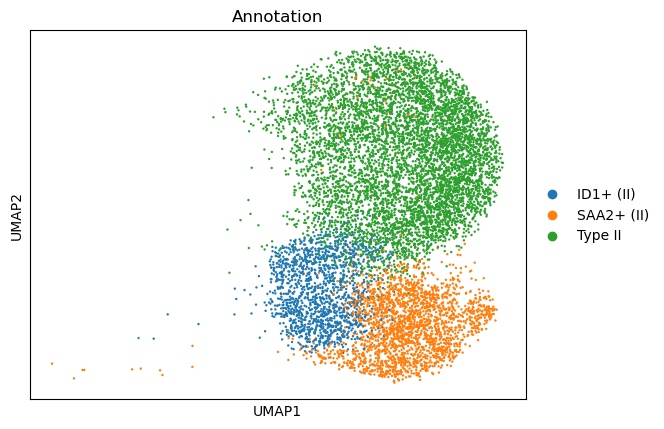

In [16]:
sc.pl.embedding(adata, basis='UMAP', color=['Annotation'])

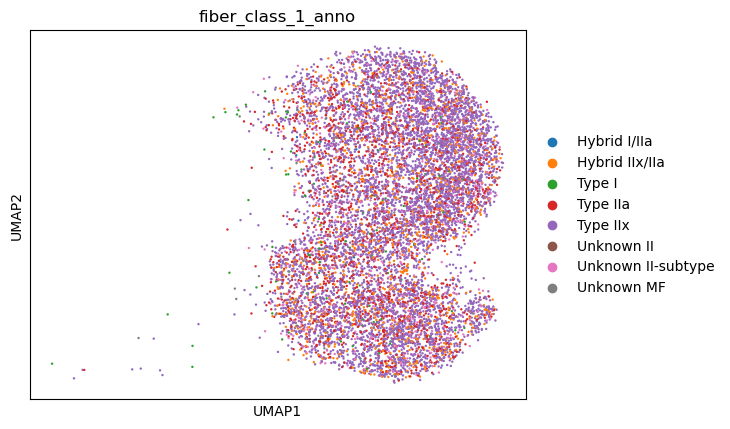

In [17]:
sc.pl.embedding(adata, basis='UMAP', color=['fiber_class_1_anno'])

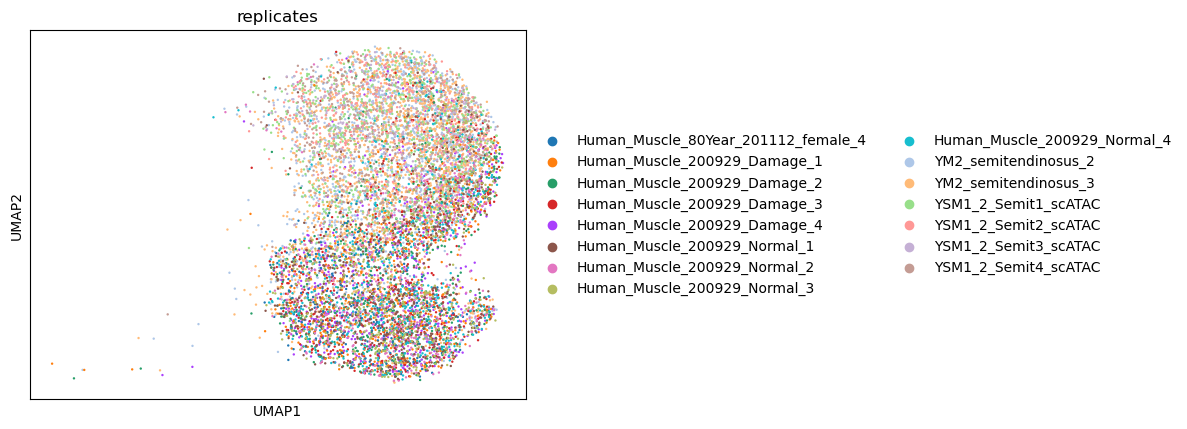

In [19]:
sc.pl.embedding(adata, basis='UMAP', color=['replicates'])

## Build layer from raw fragment files

In [ ]:
# write to file 
adata.write_h5ad(f"{export_dir}/atac_female_type2.h5ad")
